In [3]:
import numpy as np
import pandas as pd

speed = pd.read_csv("../data/speedtests.csv")
towers = pd.read_csv("../data/bahrain_towers.csv")

In [24]:
speed.columns

Index(['date', 'latitude', 'longitude', 'avg_d_mbps', 'avg_u_mbps',
       'avg_lat_ms', 'tests', 'block_number', 'city', 'area', 'typeOfArea',
       'region', 'digital_elevation_model', 'last_modified_date'],
      dtype='object')

In [28]:
[speed.columns[0].strip()]

['date']

In [29]:
[c.strip() for c in speed.columns]

['date',
 'latitude',
 'longitude',
 'avg_d_mbps',
 'avg_u_mbps',
 'avg_lat_ms',
 'tests',
 'block_number',
 'city',
 'area',
 'typeOfArea',
 'region',
 'digital_elevation_model',
 'last_modified_date']

In [6]:
speed.columns = [c.strip() for c in speed.columns]
towers.columns = [c.strip() for c in towers.columns]

In [7]:
speed["date"] = pd.to_datetime(speed["date"], format="%m/%d/%Y", errors="coerce")
speed["year"] = speed["date"].dt.year
speed["quarter"] = speed["date"].dt.quarter

In [8]:
speed.columns

Index(['date', 'latitude', 'longitude', 'avg_d_mbps', 'avg_u_mbps',
       'avg_lat_ms', 'tests', 'block_number', 'city', 'area', 'typeOfArea',
       'region', 'digital_elevation_model', 'last_modified_date', 'year',
       'quarter'],
      dtype='object')

In [9]:
speed["date"].isna().sum()

np.int64(0)

In [10]:
speed["year"].value_counts().sort_index()

year
2020     5186
2021     5188
2022     6439
2023     6201
2024    12221
2025     4790
Name: count, dtype: int64

In [11]:
speed["quarter"].value_counts().sort_index()

quarter
1     7612
2     7443
3    17203
4     7767
Name: count, dtype: int64

In [12]:
speed.head(5)

,date,latitude,longitude,avg_d_mbps,avg_u_mbps,avg_lat_ms,tests,block_number,city,area,typeOfArea,region,digital_elevation_model,last_modified_date,year,quarter
0,2020-01-01,26.286027,50.578308,4.029,3.417,22,1,228,Al Busaytin,Jazirat as Sayah,ISLX,Muharraq Governorate,-9999,6/10/2020,2020,1
1,2020-01-01,26.310651,50.622253,11.932,3.027,22,1,263,Khasaifa Island,Khasaifa Island,ISL,Muharraq Governorate,-9999,7/9/2020,2020,1
2,2020-01-01,26.305726,50.622253,32.232,17.256,28,87,263,Khasaifa Island,Khasaifa Island,ISL,Muharraq Governorate,-9999,7/9/2020,2020,1
3,2020-01-01,26.286027,50.600281,23.765,17.882,18,2,228,Al Busaytin,Jazirat as Sayah,ISLX,Muharraq Governorate,-9999,6/10/2020,2020,1
4,2020-01-01,26.281102,50.583801,29.366,4.510,22,1,228,Al Busaytin,Jazirat as Sayah,ISLX,Muharraq Governorate,-9999,6/10/2020,2020,1


In [37]:
speed.tail(5)

,date,latitude,longitude,avg_d_mbps,avg_u_mbps,avg_lat_ms,tests,block_number,city,area,typeOfArea,region,digital_elevation_model,last_modified_date,year,quarter
40020,2025-10-01,25.728158,50.798035,24.987,12.808,20,3,999,Jazirat `Ajirah,Jazirat `Ajirah,ISL,Southern Governorate,4,6/10/2020,2025,4
40021,2025-10-01,25.703413,50.776062,103.508,25.592,21,6,999,Al Hayiya Island,Al Hayiya Island,ISL,Southern Governorate,6,8/3/2016,2025,4
40022,2025-10-01,25.698463,50.770569,57.552,43.786,19,1,999,Al Hayiya Island,Al Hayiya Island,ISL,Southern Governorate,6,8/3/2016,2025,4
40023,2025-10-01,25.648954,50.737610,190.958,12.248,21,1,999,Jazirat Hawar,Jazirat Hawar,ISL,Southern Governorate,3,6/10/2020,2025,4
40024,2025-10-01,25.648954,50.743103,7.973,6.755,163,1,999,Jazirat Hawar,Jazirat Hawar,ISL,Southern Governorate,3,6/10/2020,2025,4


In [13]:
speed.dtypes

date                       datetime64[ns]
latitude                          float64
longitude                         float64
avg_d_mbps                        float64
avg_u_mbps                        float64
avg_lat_ms                          int64
tests                               int64
block_number                        int64
city                               object
area                               object
typeOfArea                         object
region                             object
digital_elevation_model             int64
last_modified_date                 object
year                                int32
quarter                             int32
dtype: object

In [14]:
towers.dtypes

Site ID          int64
Region ID        int64
RAT Type        object
RAT SubType     object
Latitude       float64
Longitude      float64
Bands           object
Channels        object
First Seen      object
Last Seen       object
Visible           bool
Tower Type      object
Operator        object
dtype: object

In [269]:
speed.head(2)

,date,latitude,longitude,avg_d_mbps,avg_u_mbps,avg_lat_ms,tests,block_number,city,area,...,tower_count_1km,tower_count_2km,tower_count_5km,region_enc,typeOfArea_enc,city_enc,demand_growth_pct_x,demand_growth_pct_y,demand_growth_pct,visible_tower_count_5km
0,2020-01-01,26.286027,50.578308,4.029,3.417,22,1,228,Al Busaytin,Jazirat as Sayah,...,0,3,245,1,3,11,0.0,0.0,0.0,172
1,2020-01-01,26.310651,50.622253,11.932,3.027,22,1,263,Khasaifa Island,Khasaifa Island,...,0,3,73,1,1,101,0.0,0.0,0.0,51


In [44]:
towers.head(5)

,Site ID,Region ID,RAT Type,RAT SubType,Latitude,Longitude,Bands,Channels,First Seen,Last Seen,Visible,Tower Type,Operator
0,700483,4,LTE,LTE-A,26.145101,50.507601,3,"1350, 1350",3/7/2021,3/7/2021,False,NaN,Zain
1,700453,2,LTE,LTE-A,26.227500,50.527800,"3, 1, 20","1350, 101, 6300, 1350, 101, 6300",3/3/2021,9/6/2022,True,MACRO,Zain
2,700531,1,LTE,LTE-A,26.260801,50.603000,"3, 1","1350, 1350, 101",3/3/2021,9/4/2022,True,MACRO,Zain
3,700069,2,LTE,LTE-A,26.242001,50.583600,"3, 1","1350, 101, 1350, 1350, 101",12/30/2020,4/19/2021,True,MACRO,Zain
4,700273,2,LTE,LTE-A,26.214800,50.592601,"3, 41","1350, 41514, 1350",4/19/2020,4/21/2021,True,MACRO,Zain


In [15]:
speed_numeric_cols = [
    "latitude", "longitude", "avg_d_mbps", "avg_u_mbps",
    "avg_lat_ms", "tests", "digital_elevation_model"
]

for col in speed_numeric_cols:
    if col in speed.columns:
        speed[col] = pd.to_numeric(speed[col], errors="coerce")

tower_numeric_cols = ["Latitude", "Longitude"]
for col in tower_numeric_cols:
    if col in towers.columns:
        towers[col] = pd.to_numeric(towers[col], errors="coerce")

In [16]:
speed_text_cols = ["block_number", "city", "area", "typeOfArea", "region"]
for col in speed_text_cols:
    if col in speed.columns:
        speed[col] = speed[col].astype(str).str.strip()

tower_text_cols = ["Operator", "RAT Type", "RAT SubType", "Tower Type", "Bands"]
for col in tower_text_cols:
    if col in towers.columns:
        towers[col] = towers[col].astype(str).str.strip()
        towers.loc[towers[col].isin(["nan", "None", ""]), col] = np.nan
        

In [17]:
speed.isnull().sum()

date                       0
latitude                   0
longitude                  0
avg_d_mbps                 0
avg_u_mbps                 0
avg_lat_ms                 0
tests                      0
block_number               0
city                       0
area                       0
typeOfArea                 0
region                     0
digital_elevation_model    0
last_modified_date         0
year                       0
quarter                    0
dtype: int64

In [132]:
speed.dtypes

date                       datetime64[ns]
latitude                          float64
longitude                         float64
avg_d_mbps                        float64
avg_u_mbps                        float64
avg_lat_ms                          int64
tests                               int64
block_number                        int64
city                               object
area                               object
typeOfArea                         object
region                             object
digital_elevation_model             int64
last_modified_date                 object
year                                int32
quarter                             int32
dtype: object

In [50]:
tower_numeric_cols

['Latitude', 'Longitude']

In [51]:
tower_text_cols

['Operator', 'RAT Type', 'RAT SubType', 'Tower Type', 'Bands']

In [54]:
speed_numeric_cols

['latitude',
 'longitude',
 'avg_d_mbps',
 'avg_u_mbps',
 'avg_lat_ms',
 'tests',
 'block_number',
 'digital_elevation_model']

In [65]:
speed_text_cols

['block_number', 'city', 'area', 'typeOfArea', 'region']

In [18]:
speed = speed.dropna(subset=[
    "latitude", "longitude", "avg_d_mbps", "avg_u_mbps",
    "avg_lat_ms", "year", "quarter"
]).copy()

towers = towers.dropna(subset=["Latitude", "Longitude"]).copy()

In [19]:
speed = speed[
    (speed["avg_d_mbps"] >= 0) &
    (speed["avg_u_mbps"] >= 0) &
    (speed["avg_lat_ms"] >= 0)
].copy()

In [20]:
speed.to_csv("../outputs/speedtests_clean.csv", index=False)
towers.to_csv("../outputs/towers_clean.csv", index=False)

print(speed.shape)
print(towers.shape)

(40025, 16)
(2994, 13)


In [21]:
speed.groupby(['year']).year.value_counts()

year
2020     5186
2021     5188
2022     6439
2023     6201
2024    12221
2025     4790
Name: count, dtype: int64

In [89]:
bad_Data = [speed['avg_lat_ms']>2000]
bad_Data.count

<function list.count(value, /)>

In [90]:
speed

,date,latitude,longitude,avg_d_mbps,avg_u_mbps,avg_lat_ms,tests,block_number,city,area,typeOfArea,region,digital_elevation_model,last_modified_date,year,quarter
0,2020-01-01,26.286027,50.578308,4.029,3.417,22,1,228,Al Busaytin,Jazirat as Sayah,ISLX,Muharraq Governorate,-9999,6/10/2020,2020,1
1,2020-01-01,26.310651,50.622253,11.932,3.027,22,1,263,Khasaifa Island,Khasaifa Island,ISL,Muharraq Governorate,-9999,7/9/2020,2020,1
2,2020-01-01,26.305726,50.622253,32.232,17.256,28,87,263,Khasaifa Island,Khasaifa Island,ISL,Muharraq Governorate,-9999,7/9/2020,2020,1
3,2020-01-01,26.286027,50.600281,23.765,17.882,18,2,228,Al Busaytin,Jazirat as Sayah,ISLX,Muharraq Governorate,-9999,6/10/2020,2020,1
4,2020-01-01,26.281102,50.583801,29.366,4.510,22,1,228,Al Busaytin,Jazirat as Sayah,ISLX,Muharraq Governorate,-9999,6/10/2020,2020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40020,2025-10-01,25.728158,50.798035,24.987,12.808,20,3,999,Jazirat `Ajirah,Jazirat `Ajirah,ISL,Southern Governorate,4,6/10/2020,2025,4
40021,2025-10-01,25.703413,50.776062,103.508,25.592,21,6,999,Al Hayiya Island,Al Hayiya Island,ISL,Southern Governorate,6,8/3/2016,2025,4
40022,2025-10-01,25.698463,50.770569,57.552,43.786,19,1,999,Al Hayiya Island,Al Hayiya Island,ISL,Southern Governorate,6,8/3/2016,2025,4
40023,2025-10-01,25.648954,50.737610,190.958,12.248,21,1,999,Jazirat Hawar,Jazirat Hawar,ISL,Southern Governorate,3,6/10/2020,2025,4


In [133]:
speed.columns

Index(['date', 'latitude', 'longitude', 'avg_d_mbps', 'avg_u_mbps',
       'avg_lat_ms', 'tests', 'block_number', 'city', 'area', 'typeOfArea',
       'region', 'digital_elevation_model', 'last_modified_date', 'year',
       'quarter'],
      dtype='object')

In [101]:
speed[speed['digital_elevation_model'] == -9999].count()

date                       4888
latitude                   4888
longitude                  4888
avg_d_mbps                 4888
avg_u_mbps                 4888
avg_lat_ms                 4888
tests                      4888
block_number               4888
city                       4888
area                       4888
typeOfArea                 4888
region                     4888
digital_elevation_model    4888
last_modified_date         4888
year                       4888
quarter                    4888
dtype: int64

In [102]:
speed['digital_elevation_model'] = speed['digital_elevation_model'].replace(-9999, pd.NA)

In [103]:
speed['digital_elevation_model'] = speed['digital_elevation_model'].fillna(speed['digital_elevation_model'].median())

C:\Users\fatma\AppData\Local\Temp\ipykernel_26956\782357996.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  speed['digital_elevation_model'] = speed['digital_elevation_model'].fillna(speed['digital_elevation_model'].median())


In [104]:
speed[speed['digital_elevation_model'] == -9999].count()

date                       0
latitude                   0
longitude                  0
avg_d_mbps                 0
avg_u_mbps                 0
avg_lat_ms                 0
tests                      0
block_number               0
city                       0
area                       0
typeOfArea                 0
region                     0
digital_elevation_model    0
last_modified_date         0
year                       0
quarter                    0
dtype: int64

In [108]:
speed.isnull().sum()

date                       0
latitude                   0
longitude                  0
avg_d_mbps                 0
avg_u_mbps                 0
avg_lat_ms                 0
tests                      0
block_number               0
city                       0
area                       0
typeOfArea                 0
region                     0
digital_elevation_model    0
last_modified_date         0
year                       0
quarter                    0
dtype: int64

In [111]:
towers.isnull().sum()

Site ID        0
Region ID      0
RAT Type       0
RAT SubType    0
Latitude       0
Longitude      0
Bands          0
Channels       0
First Seen     0
Last Seen      0
Visible        0
Tower Type     8
Operator       0
dtype: int64

In [112]:
towers['Tower Type'] = towers['Tower Type'].fillna('UNKNOWN')

In [113]:
towers.isnull().sum()

Site ID        0
Region ID      0
RAT Type       0
RAT SubType    0
Latitude       0
Longitude      0
Bands          0
Channels       0
First Seen     0
Last Seen      0
Visible        0
Tower Type     0
Operator       0
dtype: int64

In [123]:
active_towers = towers[towers['Visible'] == True].reset_index(drop=True)

In [124]:
active_towers

,Site ID,Region ID,RAT Type,RAT SubType,Latitude,Longitude,Bands,Channels,First Seen,Last Seen,Visible,Tower Type,Operator
0,700453,2,LTE,LTE-A,26.227500,50.527800,"3, 1, 20","1350, 101, 6300, 1350, 101, 6300",3/3/2021,9/6/2022,True,MACRO,Zain
1,700531,1,LTE,LTE-A,26.260801,50.603000,"3, 1","1350, 1350, 101",3/3/2021,9/4/2022,True,MACRO,Zain
2,700069,2,LTE,LTE-A,26.242001,50.583600,"3, 1","1350, 101, 1350, 1350, 101",12/30/2020,4/19/2021,True,MACRO,Zain
3,700273,2,LTE,LTE-A,26.214800,50.592601,"3, 41","1350, 41514, 1350",4/19/2020,4/21/2021,True,MACRO,Zain
4,700361,1,LTE,LTE-A,26.287501,50.637900,"3, 1","1350, 101, 1350",2/20/2021,3/3/2021,True,MACRO,Zain
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,700303,4,NR,NR,26.220560,50.396002,3,1350,9/2/2021,9/2/2021,True,MACRO,STC
2102,700303,4,NR,NR,26.221695,50.393391,3,1350,9/3/2021,9/3/2021,True,MACRO,STC
2103,700303,4,NR,NR,26.180355,50.438088,3,1350,9/4/2021,9/4/2021,True,MACRO,STC
2104,700303,4,NR,NR,26.068159,50.525496,3,1350,9/5/2021,9/5/2021,True,MACRO,STC


In [125]:
active_towers.groupby(['Operator'])['Visible'].value_counts()

Operator  Visible
Batelco   True       1892
STC       True         55
Zain      True        159
Name: count, dtype: int64

In [126]:
active_towers['RAT Type'].value_counts()

RAT Type
LTE    1966
NR      140
Name: count, dtype: int64

In [128]:
towers

,Site ID,Region ID,RAT Type,RAT SubType,Latitude,Longitude,Bands,Channels,First Seen,Last Seen,Visible,Tower Type,Operator
0,700483,4,LTE,LTE-A,26.145101,50.507601,3,"1350, 1350",3/7/2021,3/7/2021,False,NaN,Zain
1,700453,2,LTE,LTE-A,26.227500,50.527800,"3, 1, 20","1350, 101, 6300, 1350, 101, 6300",3/3/2021,9/6/2022,True,MACRO,Zain
2,700531,1,LTE,LTE-A,26.260801,50.603000,"3, 1","1350, 1350, 101",3/3/2021,9/4/2022,True,MACRO,Zain
3,700069,2,LTE,LTE-A,26.242001,50.583600,"3, 1","1350, 101, 1350, 1350, 101",12/30/2020,4/19/2021,True,MACRO,Zain
4,700273,2,LTE,LTE-A,26.214800,50.592601,"3, 41","1350, 41514, 1350",4/19/2020,4/21/2021,True,MACRO,Zain
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2989,700303,4,NR,NR,26.220560,50.396002,3,1350,9/2/2021,9/2/2021,True,MACRO,STC
2990,700303,4,NR,NR,26.221695,50.393391,3,1350,9/3/2021,9/3/2021,True,MACRO,STC
2991,700303,4,NR,NR,26.180355,50.438088,3,1350,9/4/2021,9/4/2021,True,MACRO,STC
2992,700303,4,NR,NR,26.068159,50.525496,3,1350,9/5/2021,9/5/2021,True,MACRO,STC


In [134]:
speed.columns

Index(['date', 'latitude', 'longitude', 'avg_d_mbps', 'avg_u_mbps',
       'avg_lat_ms', 'tests', 'block_number', 'city', 'area', 'typeOfArea',
       'region', 'digital_elevation_model', 'last_modified_date', 'year',
       'quarter'],
      dtype='object')

In [135]:
EARTH_RADIUS_KM = 6371.0088

In [136]:
import numpy as np

def to_radians(df, lat_col, lon_col):
    return np.deg2rad(df[[lat_col, lon_col]].to_numpy(dtype=float))

speed_coords = to_radians(speed, "latitude", "longitude")

In [137]:
type(speed_coords)

numpy.ndarray

In [228]:
active_towers.columns

Index(['Site ID', 'Region ID', 'RAT Type', 'RAT SubType', 'Latitude',
       'Longitude', 'Bands', 'Channels', 'First Seen', 'Last Seen', 'Visible',
       'Tower Type', 'Operator'],
      dtype='object')

In [229]:
tower_coords = to_radians(active_towers, "Latitude", "Longitude")

In [230]:
tower_coords

array([[0.45775624, 0.88187648],
       [0.45833744, 0.88318896],
       [0.45800932, 0.88285037],
       ...,
       [0.4569334 , 0.8803107 ],
       [0.4549752 , 0.88183625],
       [0.45177157, 0.88128729]])

In [231]:
from sklearn.neighbors import BallTree
tree = BallTree(tower_coords, metric="haversine")

In [232]:
#Find the neearest (1) tower to the speedtest record, index of the tower, and the distence (how far) it is in radiance
dist_rad, ind = tree.query(speed_coords, k=1)
speed["nearest_tower_distance_km"] = dist_rad[:, 0] * EARTH_RADIUS_KM

In [233]:
speed.tail(10)

,date,latitude,longitude,avg_d_mbps,avg_u_mbps,avg_lat_ms,tests,block_number,city,area,...,year,quarter,nearest_tower_distance_km,tower_count_1km,tower_count_2km,tower_count_5km,region_enc,typeOfArea_enc,city_enc,demand_growth_pct
40015,2025-10-01,26.093788,50.627747,172.122,14.584,8,1,952,Halat Umm al Bayd,Ra's Zuwayyid,...,2025,4,2.448600,0,0,6,0,7,73,-0.713974
40016,2025-10-01,26.083921,50.627747,242.191,42.364,17,5,952,`Askar,Ra's Zuwayyid,...,2025,4,2.829574,0,0,7,0,7,142,-0.713974
40017,2025-10-01,26.078988,50.627747,220.642,25.543,24,3,952,`Askar,Ra's Abu Jarjur,...,2025,4,2.404074,0,0,7,0,7,142,-0.720461
40018,2025-10-01,26.014829,50.627747,877.434,77.382,9,1,957,Jaww,Jaww,...,2025,4,1.326488,0,1,3,3,4,81,-0.763736
40019,2025-10-01,26.009893,50.627747,143.202,18.075,9,1,957,Jaww,Jaww,...,2025,4,1.724564,0,1,3,3,4,81,-0.763736
40020,2025-10-01,25.728158,50.798035,24.987,12.808,20,3,999,Jazirat `Ajirah,Jazirat `Ajirah,...,2025,4,23.572317,0,0,0,3,1,85,-0.772727
40021,2025-10-01,25.703413,50.776062,103.508,25.592,21,6,999,Al Hayiya Island,Al Hayiya Island,...,2025,4,23.769754,0,0,0,3,1,15,-0.886640
40022,2025-10-01,25.698463,50.770569,57.552,43.786,19,1,999,Al Hayiya Island,Al Hayiya Island,...,2025,4,23.797679,0,0,0,3,1,15,-0.886640
40023,2025-10-01,25.648954,50.737610,190.958,12.248,21,1,999,Jazirat Hawar,Jazirat Hawar,...,2025,4,26.400552,0,0,0,3,1,82,-0.871287
40024,2025-10-01,25.648954,50.743103,7.973,6.755,163,1,999,Jazirat Hawar,Jazirat Hawar,...,2025,4,26.668311,0,0,0,3,1,82,-0.871287


In [234]:
speed["nearest_tower_distance_km"]<=1

0        False
1        False
2         True
3         True
4         True
         ...  
40020    False
40021    False
40022    False
40023    False
40024    False
Name: nearest_tower_distance_km, Length: 40025, dtype: bool

In [235]:
#radiance = km / earth radius
# km = radiance * earth radius

for radius_km in [1, 2, 5]:
    r = radius_km / EARTH_RADIUS_KM
    idxs = tree.query_radius(speed_coords, r=r)
    speed[f"tower_count_{radius_km}km"] = [len(x) for x in idxs]

In [236]:
speed["tower_count_5km"]

0        245
1         73
2        101
3        312
4        432
        ... 
40020      0
40021      0
40022      0
40023      0
40024      0
Name: tower_count_5km, Length: 40025, dtype: int64

In [237]:
speed

,date,latitude,longitude,avg_d_mbps,avg_u_mbps,avg_lat_ms,tests,block_number,city,area,...,year,quarter,nearest_tower_distance_km,tower_count_1km,tower_count_2km,tower_count_5km,region_enc,typeOfArea_enc,city_enc,demand_growth_pct
0,2020-01-01,26.286027,50.578308,4.029,3.417,22,1,228,Al Busaytin,Jazirat as Sayah,...,2020,1,1.481096,0,3,245,1,3,11,0.000000
1,2020-01-01,26.310651,50.622253,11.932,3.027,22,1,263,Khasaifa Island,Khasaifa Island,...,2020,1,1.170087,0,3,73,1,1,101,0.000000
2,2020-01-01,26.305726,50.622253,32.232,17.256,28,87,263,Khasaifa Island,Khasaifa Island,...,2020,1,0.622651,1,3,101,1,1,101,0.000000
3,2020-01-01,26.286027,50.600281,23.765,17.882,18,2,228,Al Busaytin,Jazirat as Sayah,...,2020,1,0.399815,3,5,312,1,3,11,0.000000
4,2020-01-01,26.281102,50.583801,29.366,4.510,22,1,228,Al Busaytin,Jazirat as Sayah,...,2020,1,0.713119,1,3,432,1,3,11,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40020,2025-10-01,25.728158,50.798035,24.987,12.808,20,3,999,Jazirat `Ajirah,Jazirat `Ajirah,...,2025,4,23.572317,0,0,0,3,1,85,-0.772727
40021,2025-10-01,25.703413,50.776062,103.508,25.592,21,6,999,Al Hayiya Island,Al Hayiya Island,...,2025,4,23.769754,0,0,0,3,1,15,-0.886640
40022,2025-10-01,25.698463,50.770569,57.552,43.786,19,1,999,Al Hayiya Island,Al Hayiya Island,...,2025,4,23.797679,0,0,0,3,1,15,-0.886640
40023,2025-10-01,25.648954,50.737610,190.958,12.248,21,1,999,Jazirat Hawar,Jazirat Hawar,...,2025,4,26.400552,0,0,0,3,1,82,-0.871287


In [238]:
speed["tower_count_2km"]

0        3
1        3
2        3
3        5
4        3
        ..
40020    0
40021    0
40022    0
40023    0
40024    0
Name: tower_count_2km, Length: 40025, dtype: int64

In [239]:
speed.head()

,date,latitude,longitude,avg_d_mbps,avg_u_mbps,avg_lat_ms,tests,block_number,city,area,...,year,quarter,nearest_tower_distance_km,tower_count_1km,tower_count_2km,tower_count_5km,region_enc,typeOfArea_enc,city_enc,demand_growth_pct
0,2020-01-01,26.286027,50.578308,4.029,3.417,22,1,228,Al Busaytin,Jazirat as Sayah,...,2020,1,1.481096,0,3,245,1,3,11,0.0
1,2020-01-01,26.310651,50.622253,11.932,3.027,22,1,263,Khasaifa Island,Khasaifa Island,...,2020,1,1.170087,0,3,73,1,1,101,0.0
2,2020-01-01,26.305726,50.622253,32.232,17.256,28,87,263,Khasaifa Island,Khasaifa Island,...,2020,1,0.622651,1,3,101,1,1,101,0.0
3,2020-01-01,26.286027,50.600281,23.765,17.882,18,2,228,Al Busaytin,Jazirat as Sayah,...,2020,1,0.399815,3,5,312,1,3,11,0.0
4,2020-01-01,26.281102,50.583801,29.366,4.510,22,1,228,Al Busaytin,Jazirat as Sayah,...,2020,1,0.713119,1,3,432,1,3,11,0.0


In [240]:
speed.columns

Index(['date', 'latitude', 'longitude', 'avg_d_mbps', 'avg_u_mbps',
       'avg_lat_ms', 'tests', 'block_number', 'city', 'area', 'typeOfArea',
       'region', 'digital_elevation_model', 'last_modified_date', 'year',
       'quarter', 'nearest_tower_distance_km', 'tower_count_1km',
       'tower_count_2km', 'tower_count_5km', 'region_enc', 'typeOfArea_enc',
       'city_enc', 'demand_growth_pct'],
      dtype='object')

In [155]:
#Encoding

In [25]:
from sklearn.preprocessing import LabelEncoder
import os

In [27]:
import json
encoders = {}

for col in ['region', 'typeOfArea', 'city']:
    le = LabelEncoder()
    speed[f'{col}_enc'] = le.fit_transform(speed[col].fillna('Unknown'))
    encoders[col] = {label: int(idx) for idx, label in enumerate(le.classes_)}
    print(f"{col} {len(le.classes_)} unique values")
os.makedirs('../assets', exist_ok=True)
with open('../assets/encoders.json', 'w') as f:
    json.dump(encoders, f, indent=2)

region 4 unique values
typeOfArea 9 unique values
city 145 unique values


In [174]:
#Demand growth calculation over the years - comparing number of tests year over year

In [180]:
yearly_tests = (speed.groupby(['area', 'year'])['tests'].sum().reset_index().sort_values(['area', 'year']))

In [179]:
yearly_tests.head(6)

,area,year,tests
0,A'ali,2020,366
1,A'ali,2021,293
2,A'ali,2022,313
3,A'ali,2023,353
4,A'ali,2024,487
5,A'ali,2025,258


In [244]:
#pct_change to calculate/ computes the difference between the current value and the previous
#clip to trim the values over the year, so that the comparison been done for each city year over year, and then refresh the pct calculation for the next city
yearly_tests['demand_growth_pct'] = (yearly_tests.groupby('area')['tests'].pct_change().fillna(0).clip(-1, 5))

In [245]:
yearly_tests.head(12)

,area,year,tests,demand_growth_pct
0,A'ali,2020,366,0.000000
1,A'ali,2021,293,-0.199454
2,A'ali,2022,313,0.068259
3,A'ali,2023,353,0.127796
4,A'ali,2024,487,0.379603
5,A'ali,2025,258,-0.470226
6,Abu Baham,2020,195,0.000000
7,Abu Baham,2021,158,-0.189744
8,Abu Baham,2022,221,0.398734
9,Abu Baham,2023,152,-0.312217


In [246]:
speed = speed.merge(yearly_tests[['area', 'year', 'demand_growth_pct']], on=['area', 'year'], how='left')
speed['demand_growth_pct'] = speed['demand_growth_pct'].fillna(0)

In [247]:
speed.columns

Index(['date', 'latitude', 'longitude', 'avg_d_mbps', 'avg_u_mbps',
       'avg_lat_ms', 'tests', 'block_number', 'city', 'area', 'typeOfArea',
       'region', 'digital_elevation_model', 'last_modified_date', 'year',
       'quarter', 'nearest_tower_distance_km', 'tower_count_1km',
       'tower_count_2km', 'tower_count_5km', 'region_enc', 'typeOfArea_enc',
       'city_enc', 'demand_growth_pct_x', 'demand_growth_pct_y',
       'demand_growth_pct'],
      dtype='object')

In [248]:
speed['demand_growth_pct'].mean()

np.float64(0.21693796184407216)

In [29]:
agg_dict = {
    'latitude':               'mean',
    'longitude':              'mean',
    'avg_d_mbps':             'mean',
    'avg_u_mbps':             'mean',
    'avg_lat_ms':             'mean',
    'tests':                   'sum',
    'nearest_tower_distance_km': 'mean',
    'tower_count_1km':        'mean',
    'tower_count_2km':        'mean',
    'tower_count_5km':        'mean',
    'digital_elevation_model':'mean',
    'region_enc':             'first',
    'typeOfArea_enc':         'first',
    'city_enc':               'first',
    'demand_growth_pct':      'mean',
    'region':                 'first',
    'typeOfArea':             'first',
    'city':                   'first',
    'block_number':           'first',
}

features = (speed.groupby(['area', 'year', 'quarter']).agg(agg_dict).reset_index())

KeyError: "Column(s) ['demand_growth_pct', 'nearest_tower_distance_km', 'tower_count_1km', 'tower_count_2km', 'tower_count_5km'] do not exist"

In [28]:
features

NameError: name 'features' is not defined

In [216]:
features.shape

(6086, 22)

In [217]:
features['area'].nunique()

273

In [220]:
sorted(features['year'].unique())

[np.int32(2020),
 np.int32(2021),
 np.int32(2022),
 np.int32(2023),
 np.int32(2024),
 np.int32(2025)]

In [222]:
features[['area', 'year', 'avg_d_mbps', 'tower_count_5km','nearest_tower_distance_km', 'demand_growth_pct']].head(8).to_string()

"    area  year  avg_d_mbps  tower_count_5km  nearest_tower_distance_km  demand_growth_pct\n0  A'ali  2020   34.608000       263.800000                   0.910574           0.000000\n1  A'ali  2020   24.785500       266.166667                   0.949577           0.000000\n2  A'ali  2020   28.455333       266.166667                   0.949577           0.000000\n3  A'ali  2020   51.100167       266.166667                   0.949577           0.000000\n4  A'ali  2021   50.347500       266.166667                   0.949577          -0.199454\n5  A'ali  2021   95.874667       266.166667                   0.949577          -0.199454\n6  A'ali  2021   60.233400       268.200000                   1.016811          -0.199454\n7  A'ali  2021   63.738000       262.428571                   1.090944          -0.199454"

In [251]:
features.to_csv('data/processed/features.csv', index=False)

In [252]:
speed.to_csv('data/processed/speeds_clean.csv', index=False)

In [226]:
features.shape[0]

6086

In [227]:
features.shape[1]

22

In [271]:
speed.columns

Index(['date', 'latitude', 'longitude', 'avg_d_mbps', 'avg_u_mbps',
       'avg_lat_ms', 'tests', 'block_number', 'city', 'area', 'typeOfArea',
       'region', 'digital_elevation_model', 'last_modified_date', 'year',
       'quarter', 'nearest_tower_distance_km', 'tower_count_1km',
       'tower_count_2km', 'tower_count_5km', 'region_enc', 'typeOfArea_enc',
       'city_enc', 'demand_growth_pct_x', 'demand_growth_pct_y',
       'demand_growth_pct', 'visible_tower_count_5km'],
      dtype='object')

In [277]:
speed.groupby(['year']).tests.sum()

year
2020     96420
2021     90543
2022    124163
2023     88227
2024    148716
2025     51388
Name: tests, dtype: int64

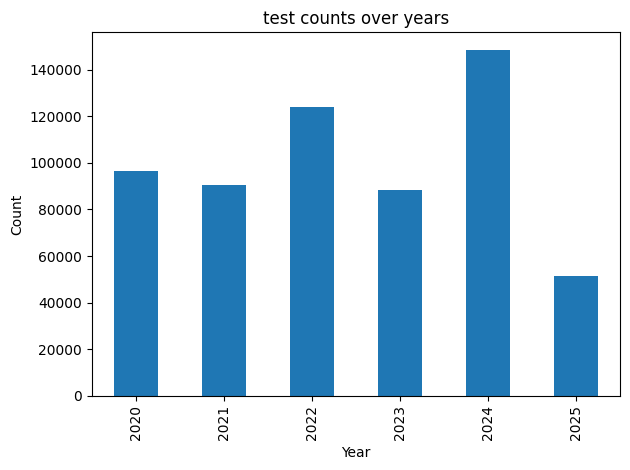

<Figure size 640x480 with 0 Axes>

In [285]:
import matplotlib.pyplot as plt
speed.groupby(['year']).tests.sum().plot(kind='bar')

plt.title('test counts over years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks()
plt.tight_layout()
plt.show()

plt.savefig('assets/figures/speedtest_count_by_year.png', dpi=150)
plt.show()

In [286]:
speed.groupby('year')[['avg_d_mbps', 'avg_u_mbps', 'avg_lat_ms']].mean().round(2)

,avg_d_mbps,avg_u_mbps,avg_lat_ms
year,,,
2020,47.76,13.25,23.83
2021,71.86,15.26,23.70
2022,137.44,20.51,23.58
2023,185.27,25.32,26.25
2024,200.00,25.58,25.24
2025,252.70,31.87,23.93


In [281]:
speed.columns

Index(['date', 'latitude', 'longitude', 'avg_d_mbps', 'avg_u_mbps',
       'avg_lat_ms', 'tests', 'block_number', 'city', 'area', 'typeOfArea',
       'region', 'digital_elevation_model', 'last_modified_date', 'year',
       'quarter', 'nearest_tower_distance_km', 'tower_count_1km',
       'tower_count_2km', 'tower_count_5km', 'region_enc', 'typeOfArea_enc',
       'city_enc', 'demand_growth_pct_x', 'demand_growth_pct_y',
       'demand_growth_pct', 'visible_tower_count_5km'],
      dtype='object')

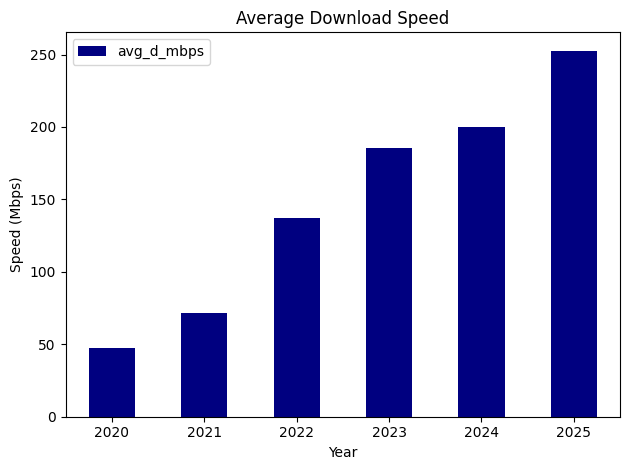

In [37]:
import matplotlib.pyplot as plt

ax = speed.groupby('year')[['avg_d_mbps']].mean().round(2).plot(
    kind='bar',
    color='navy'
)

plt.title('Average Download Speed')
plt.xlabel('Year')
plt.ylabel('Speed (Mbps)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('../assets/figures/yearly_speed3_trends_bar.png', dpi=150)

plt.show()

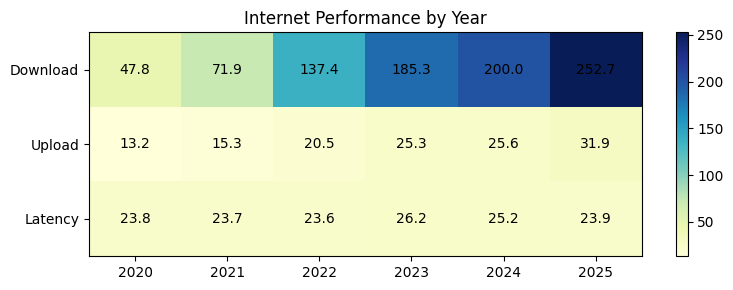

In [291]:
df_yearly = (
    speed.groupby('year')[['avg_d_mbps', 'avg_u_mbps', 'avg_lat_ms']]
    .mean()
    .round(2)
)
data = df_yearly.T
data.index = ['Download', 'Upload', 'Latency']

plt.figure(figsize=(8, 3))
plt.imshow(data, aspect='auto', cmap='YlGnBu')
plt.xticks(range(len(data.columns)), data.columns)
plt.yticks(range(len(data.index)), data.index)

for i in range(len(data.index)):
    for j in range(len(data.columns)):
        plt.text(j, i, f"{data.iloc[i, j]:.1f}",
                 ha='center', va='center', color='black')

plt.title("Internet Performance by Year")
plt.colorbar()

plt.tight_layout()
plt.savefig('assets/figures/yearly_speed_trends_heatmap.png', dpi=150)
plt.show()

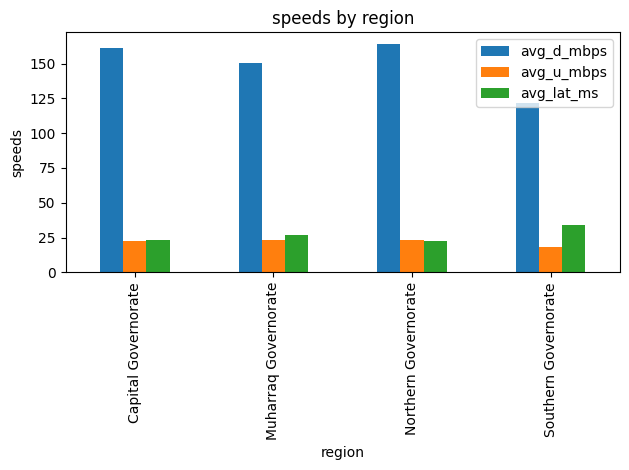

<Figure size 640x480 with 0 Axes>

In [293]:
speed.groupby('region')[['avg_d_mbps', 'avg_u_mbps', 'avg_lat_ms']].mean().round(2).plot(kind='bar')

plt.title('speeds by region')
plt.xlabel('region')
plt.ylabel('speeds')
plt.xticks()
plt.tight_layout()
plt.show()

plt.savefig('assets/figures/speed_by_region.png', dpi=150)
plt.show()

In [30]:
import pandas as pd
f = pd.read_csv('../data/processed/features.csv')

In [32]:
f['tower_count_5km']

0       184.000000
1       186.333333
2       186.333333
3       186.333333
4       186.333333
           ...    
6081    625.000000
6082    625.000000
6083    625.000000
6084    625.000000
6085    625.000000
Name: tower_count_5km, Length: 6086, dtype: float64